Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage



Step 2: Load the Dataset


In [2]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")
df


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Step 3: Select Features for Clustering

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values


Step 4: Standardize Features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


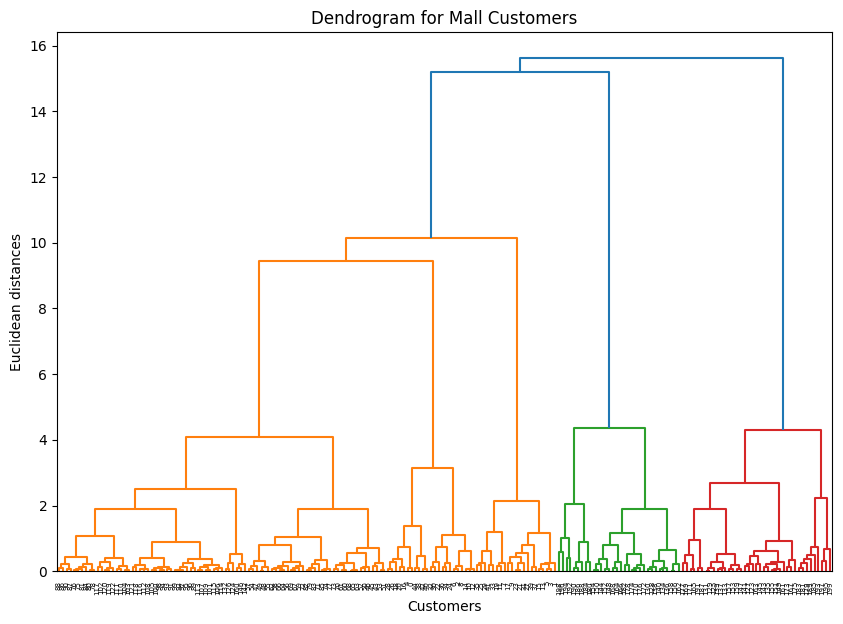

In [6]:
# Create the linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Dendrogram for Mall Customers")
plt.xlabel("Customers")
plt.ylabel("Euclidean distances")
plt.show()


In [9]:
from sklearn.cluster import AgglomerativeClustering

# Correct usage for scikit-learn 1.2+
agg_cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')  # No affinity/metric needed
cluster_labels = agg_cluster.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df['Cluster'] = cluster_labels
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,0


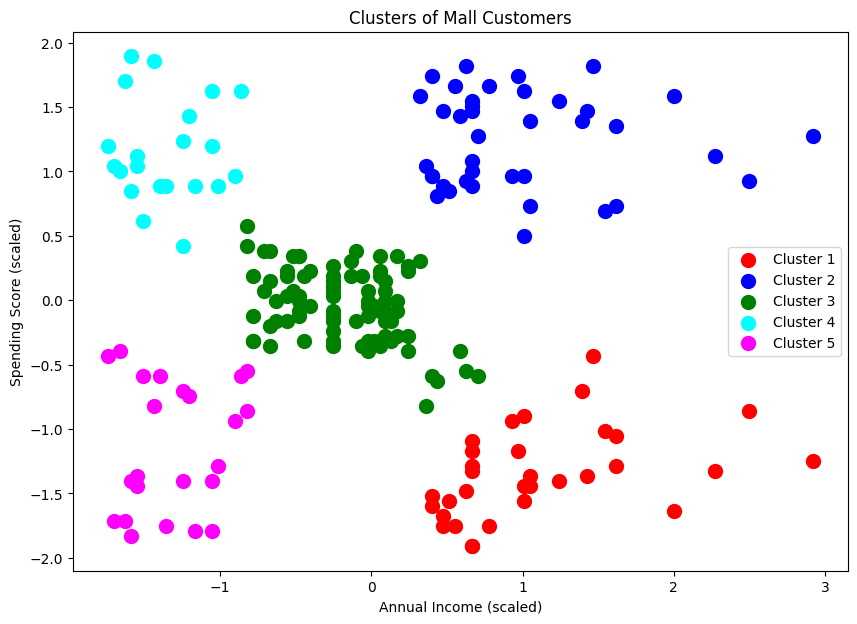

In [10]:

# Step 9: Visualize clusters
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(X_scaled[cluster_labels == i, 0], 
                X_scaled[cluster_labels == i, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')

plt.title('Clusters of Mall Customers')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.show()

In [11]:
import joblib


In [12]:
# Save the trained Agglomerative Clustering model
joblib.dump(agg_cluster, "agg_clustering_model.pkl")
print("Model saved as agg_clustering_model.pkl")


Model saved as agg_clustering_model.pkl
